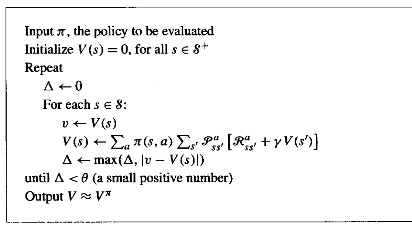

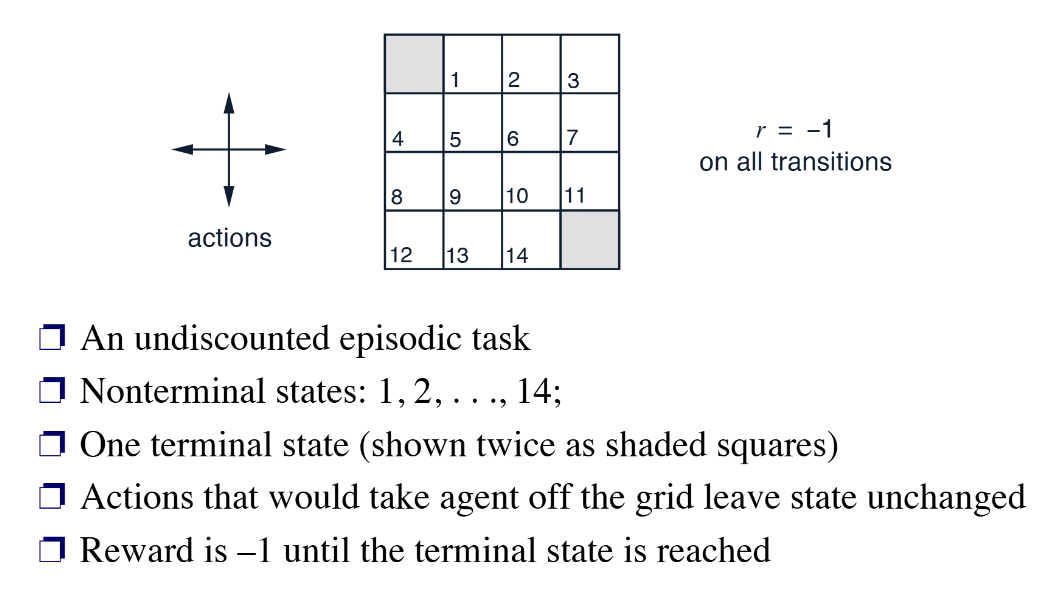

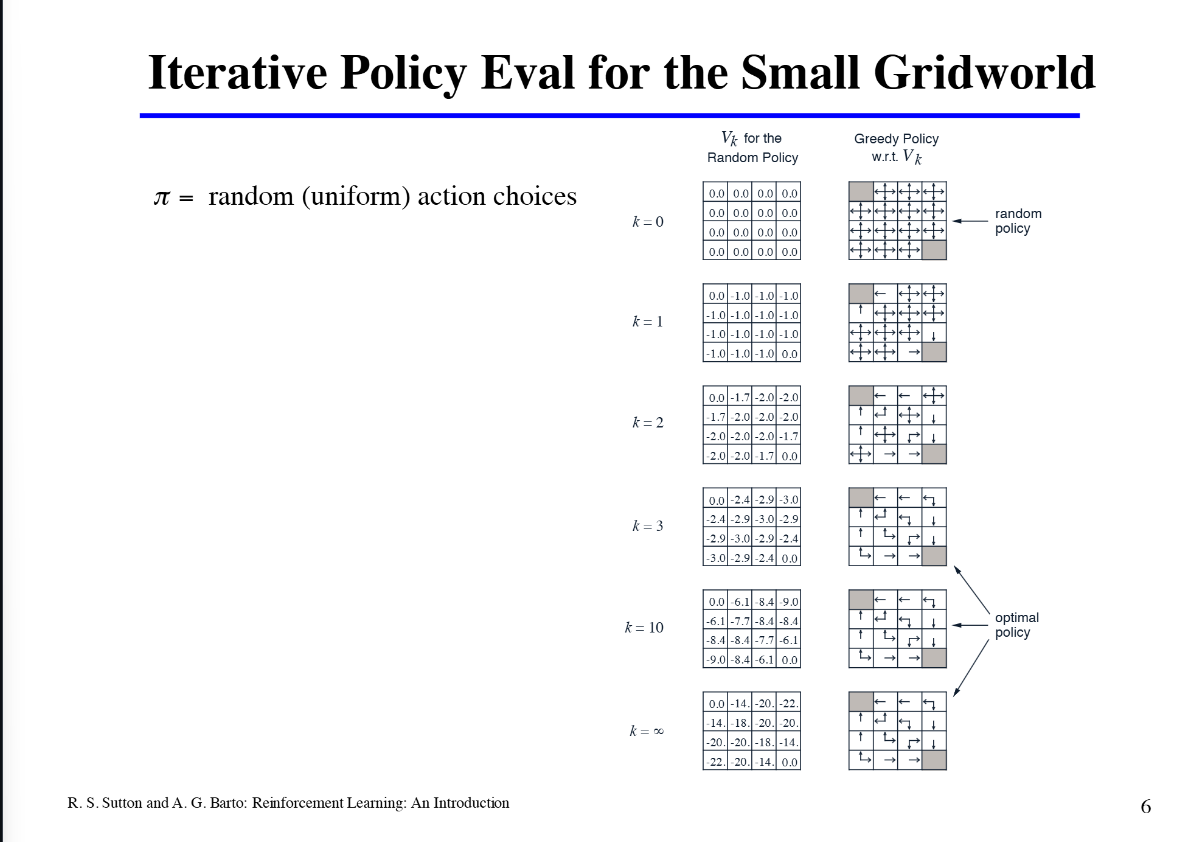

In [7]:
S = 16
sFinales = [0, 15]
V = [0.0] * S
#1 arriba, 2 abajo, 3 izquierda, 4 derecha
allA = [1, 2, 3, 4]
pA = 0.25 #Todos tienen misma prob de usar una direccion

theta = 0.0001 #La diferencia entre modelos

def siguienteEstado(eActual, accion):
    if eActual in sFinales:
      return eActual

    fila = eActual // 4
    col = eActual % 4

    if accion == 1:
        fila = fila - 1
    elif accion == 2:
        fila = fila + 1
    elif accion == 3:
        col = col - 1
    elif accion == 4:
        col = col + 1

    if fila < 0 or fila > 3 or col < 0 or col > 3:
        return eActual

    estado_siguiente = fila * 4 + col
    return estado_siguiente

iteracion = 0

while True:
  delta = 0
  V_viejo = list(V)
  for s in range(S):
    if s in sFinales:
      continue
    newVal = 0
    firstRun = True
    for a in allA:
      sSiguiente=siguienteEstado(s,a)
      newVal += pA * (-1 + V_viejo[sSiguiente]) #Como gamma es =1 y el castigo todos -1 pues directo xd
    V[s] = newVal
    diferencia = abs(V_viejo[s] - V[s])
    if diferencia > delta:
      delta = diferencia
  iteracion += 1
  print('delta maximo de la epoca ', iteracion, ' es ', delta)
  if delta < theta:
    break
print('El entrenamiento acabo en la epoca ', iteracion)


for i in range(4):
    fila_valores = []
    for j in range(4):
        estado = i * 4 + j
        fila_valores.append(f"{V[estado]:6.1f}")
    print( " | ".join(fila_valores) + " |")

delta maximo de la epoca  1  es  1.0
delta maximo de la epoca  2  es  1.0
delta maximo de la epoca  3  es  1.0
delta maximo de la epoca  4  es  0.96875
delta maximo de la epoca  5  es  0.9375
delta maximo de la epoca  6  es  0.89453125
delta maximo de la epoca  7  es  0.8544921875
delta maximo de la epoca  8  es  0.81103515625
delta maximo de la epoca  9  es  0.770751953125
delta maximo de la epoca  10  es  0.730255126953125
delta maximo de la epoca  11  es  0.6925201416015625
delta maximo de la epoca  12  es  0.6557655334472656
delta maximo de la epoca  13  es  0.6213254928588867
delta maximo de la epoca  14  es  0.5882596969604492
delta maximo de la epoca  15  es  0.5571491718292236
delta maximo de la epoca  16  es  0.527485579252243
delta maximo de la epoca  17  es  0.49950262904167175
delta maximo de la epoca  18  es  0.4729122780263424
delta maximo de la epoca  19  es  0.44778872188180685
delta maximo de la epoca  20  es  0.4239568174816668
delta maximo de la epoca  21  es  0.4014

Codigo Collab: https://colab.research.google.com/drive/1EjvQjO2mT39juD7sQb7JgFHfjOocB-WN?usp=sharing